In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
from scipy.integrate import trapezoid

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities, fit_kde_model
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd,
                            dens2lqd,
                            lqd2dens
                            )
                            

# Normal

In [105]:
mu = 0
sigma = 2
n = 256
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
grid = np.linspace(normal_sample.min(), normal_sample.max(), n)

params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
kde, density = fit_kde_model(normal_sample, params)

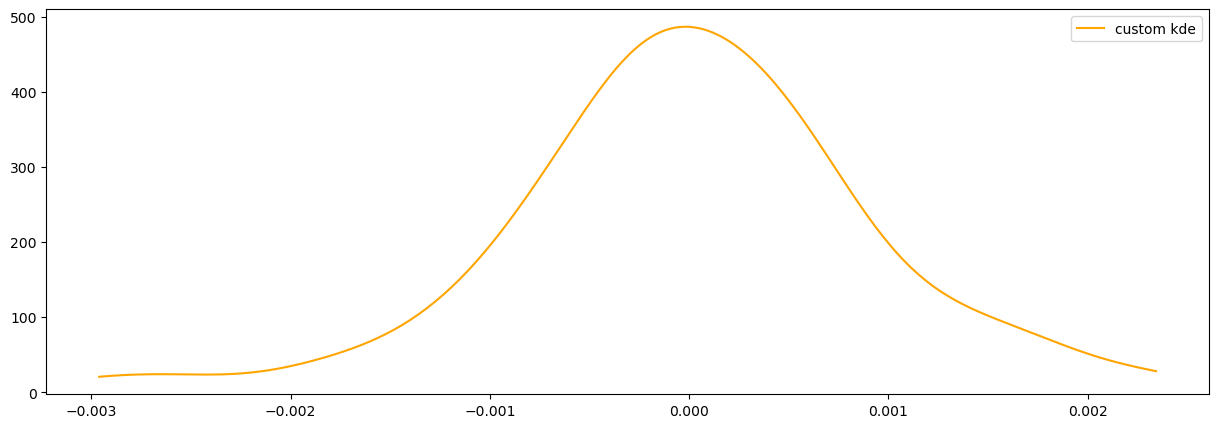

In [64]:
plt.figure(figsize=(15,5))

# sns.histplot(normal_sample, kde=True)
# sns.kdeplot(normal_sample, label="sns_kde")
sns.lineplot(x=kde.grid, y=density, color="orange", label="custom kde")

plt.show()

In [65]:
lqd_grid = np.linspace(0,1,n)
t0_ = kde.grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


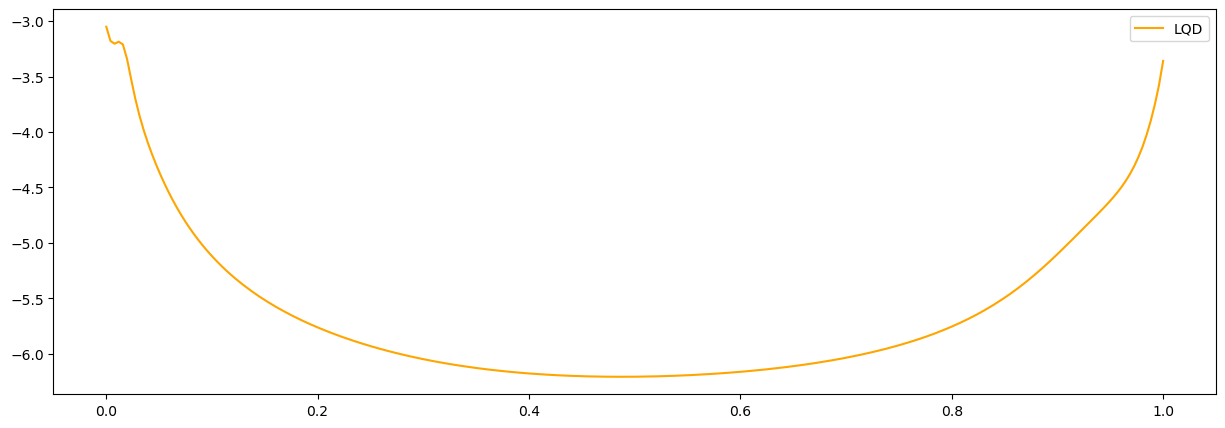

In [66]:
plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [67]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

c not in lqdSup — resetting to closest value.


In [68]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

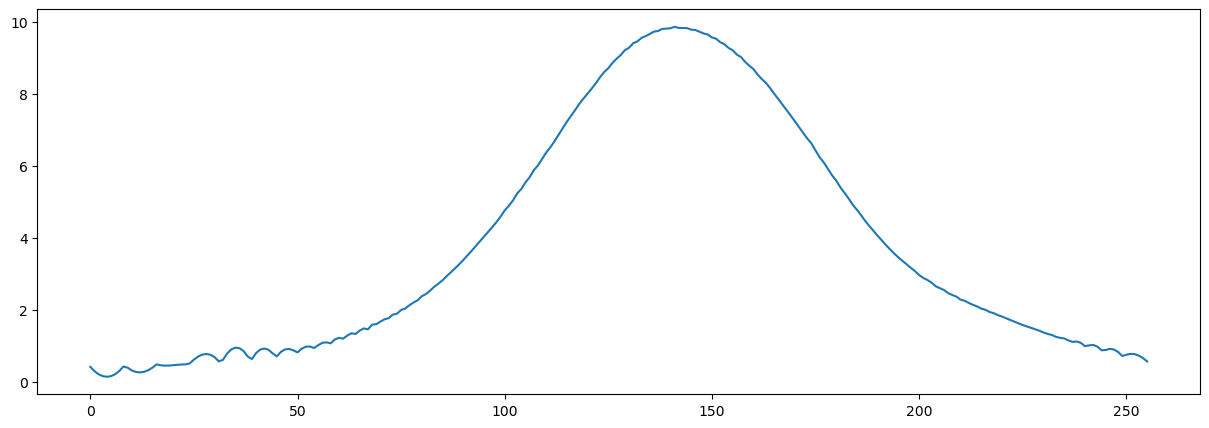

In [69]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

# Empiral density

In [7]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


In [8]:
i = 10
t = df.columns[i]
n = 256

Z_t = df.loc[:, t]
# params = {'kernel': 't_student', "df": 2, 'bandwidth': 'scott'}
params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}
# params = {'kernel': 'gaussian', 'bandwidth': 'scott'}

## Local grid

In [9]:
grid = np.linspace(Z_t.min(), Z_t.max().max(), n)

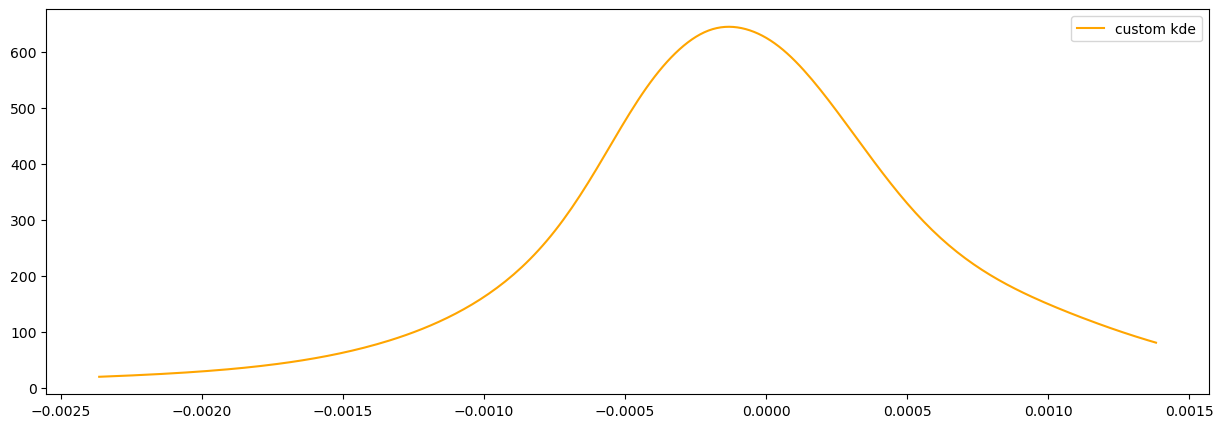

In [10]:
kde, density = fit_kde_model(Z_t, params)

plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


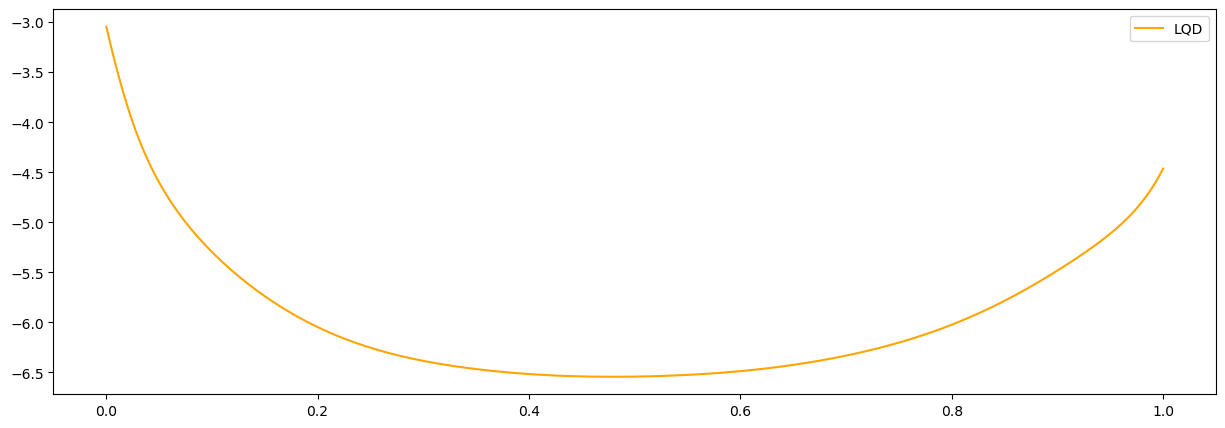

In [11]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [12]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

c not in lqdSup — resetting to closest value.


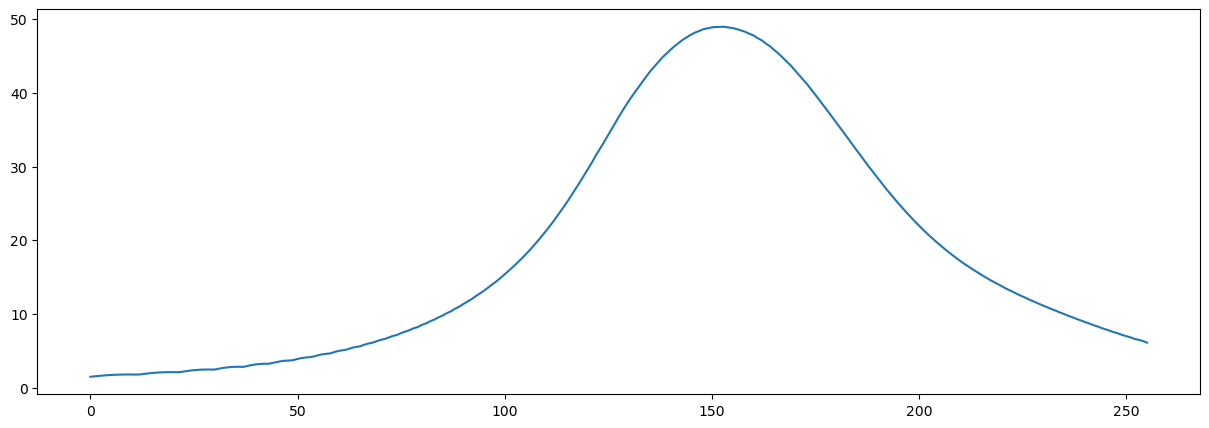

In [13]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

## Global grid

In [14]:
grid = np.linspace(df.min().min(), df.max().max(), n)

In [15]:
kde, density = fit_kde_model(Z_t, params, grid=grid)
# print(trapezoid(density/trapezoid(density, kde.grid), kde.grid))

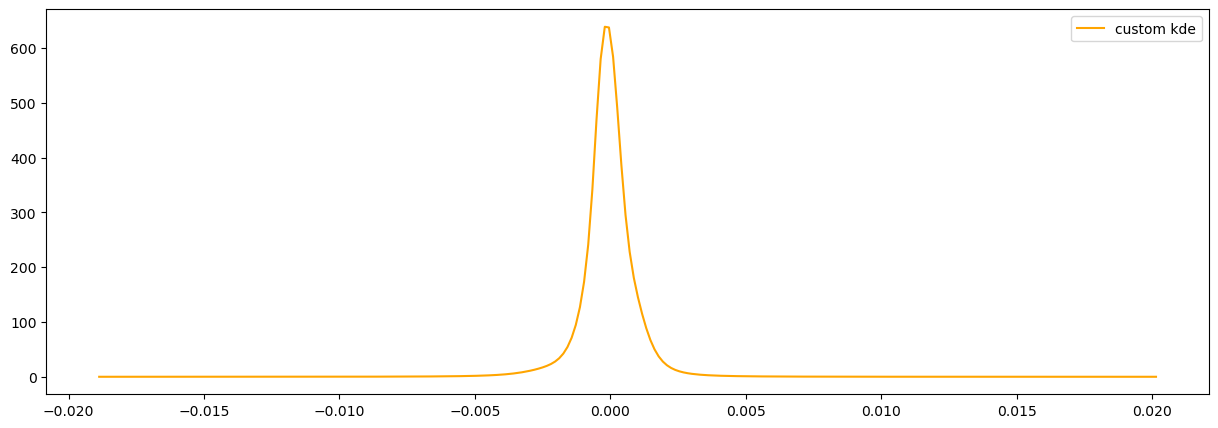

In [16]:
plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


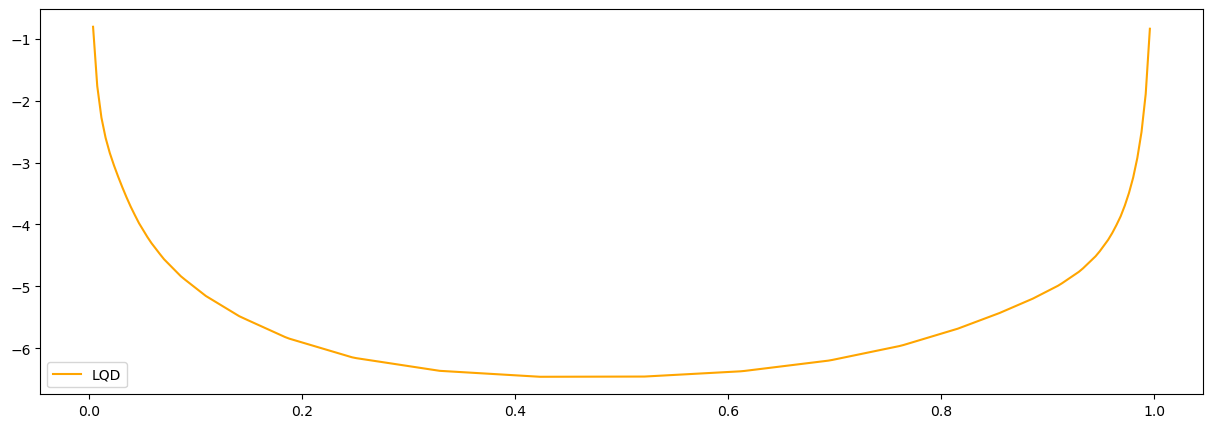

In [17]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [18]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, t0=t0_,dSup=grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

Problem with LQD domain boundaries — resetting to default.
c not in lqdSup — resetting to closest value.


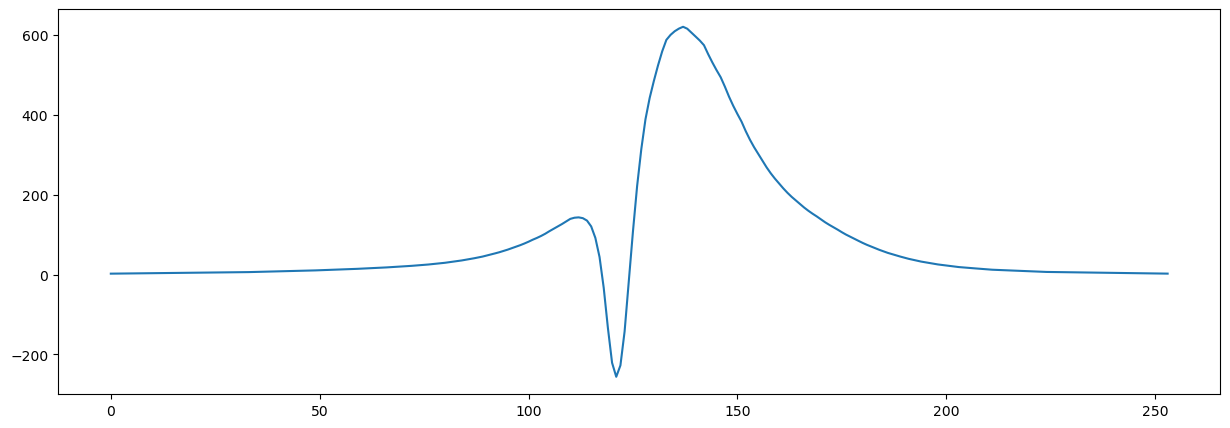

In [19]:
plt.figure(figsize=(15,5))

plt.plot(dens - density[1:-1])

plt.show()

# Versão no R - DJI_returns

In [111]:
df_r = pd.read_excel("../data/processed/r_transformation.xlsx")
df_r.sample(10)

,u,original_dens,backwards_dens
3346,-0.159268,7.010630e-01,0.701793
3533,-0.071689,4.814419e+00,4.815369
3202,-0.226708,1.365272e-03,0.000000
2903,-0.366741,5.759485e-17,0.000000
1791,-0.887530,1.186612e-16,0.000000
447,-1.516974,3.003455e-16,0.000000
4759,0.502491,0.000000e+00,0.000000
3874,0.088014,2.371724e-01,0.237371
3687,0.000435,7.005235e+00,7.003572
2073,-0.755459,2.205490e-16,0.000000


In [112]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.original_dens,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.backwards_dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

# Versão no R - Bovespa

In [21]:
i = 10
t = df.columns[i]
df_for_r = pd.DataFrame({'u': kde.grid, 'density': density})
df_for_r.to_excel("../data/interim/df_for_r.xlsx", index=False)

In [22]:
df_from_r = pd.read_excel(("../data/processed/r_transformation_bovespa_t.xlsx"))

In [23]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.backwards_density,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

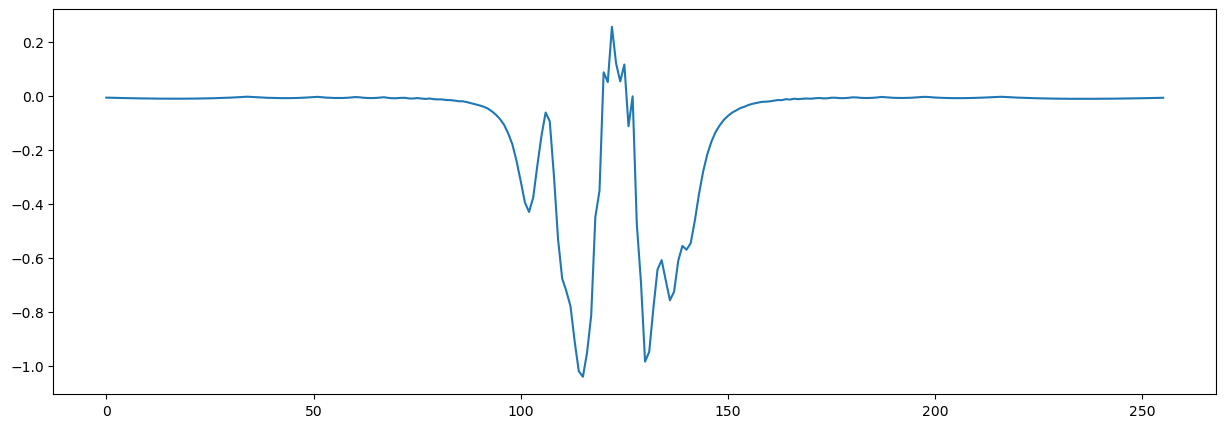

In [24]:
plt.figure(figsize=(15,5))

plt.plot(df_from_r.density - df_from_r.backwards_density)

plt.show()

# Ajusting LQDensity

In [2]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")

params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}

df_support, df_densities = df_to_densities(df, params, verbose=False)

bovespa_mLQDT = mLQDT(
                    df_densities.reset_index(drop=True),
                    df_support.reset_index(drop=True)
                )
bovespa_mLQDT.densities_to_lqdensities(verbose=False)

df_lqds = bovespa_mLQDT.lqd.iloc[1:-1,:]
df_lqds_support = bovespa_mLQDT.lqd_support[1:-1]

In [4]:
kle_bkw_supports, kle_bkw_densities = obtain_densities_from_lqd(
                                                            df_lqds,
                                                            bovespa_mLQDT.lqd_support,
                                                            bovespa_mLQDT.c,
                                                            t_=bovespa_mLQDT.t,
                                                            verbose=False
                                                            )

In [21]:
# Visualização
i = 10
t = df.columns[i]

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_support.loc[:,t],
        y=df_densities.loc[:,t],
        mode="lines",
        name="Original",
        line=dict(color="black")
    )
)

# t-kernel KDE df = 4
fig.add_trace(
    go.Scatter(
        x=kle_bkw_supports.loc[:,t],
        y=kle_bkw_densities.loc[:,t],
        mode="lines",
        name="Backwards (whole dataframe)",
        line=dict(color="green")
    )
)

fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="Backwards (standalone)",
        line=dict(color="red")
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="rgba(0,0,0,0.2)")
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="rgba(0,0,0,0.2)")

fig.update_layout(
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=160),  # make room for the legend
    title=f"{params}"
)

fig.show()